In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
import pickle
#Load oos dataset
#data_path1 = Path.home() / "Prepayment_Analysis_Data" / "mort_for_estimation.csv"
mort_est_df = pd.read_csv("~/Prepayment_Analysis_Data/prediction_df_oos.csv", header=0, parse_dates=['ORIG_DATE1', 'DATE_NOW'])
#data_path2 = Path.home() / "Prepayment_Analysis_Data" / "mort_for_prediction.csv"
#mort_pred_df = pd.read_csv(data_path2, header=0, parse_dates=['ORIG_DATE1', 'DATE_NOW'])

In [2]:
#Load logit model and get oos predictions
from statsmodels.iolib.smpickle import load_pickle
# Load the model back into memory
logit = load_pickle("cloglog_model_results.pkl")
X = mort_est_df[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
X = sm.add_constant(X)
y_logit = logit.predict(X)

In [3]:
import joblib

# Load the randomized search object back into memory
random_search = joblib.load('random_search.pkl')

scaler = StandardScaler()
X1 = mort_est_df[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
X1_scaled = scaler.fit_transform(X1)
y_boost = random_search.predict_proba(X1_scaled)[:, 1]

FEB 24 DONE TO HERE

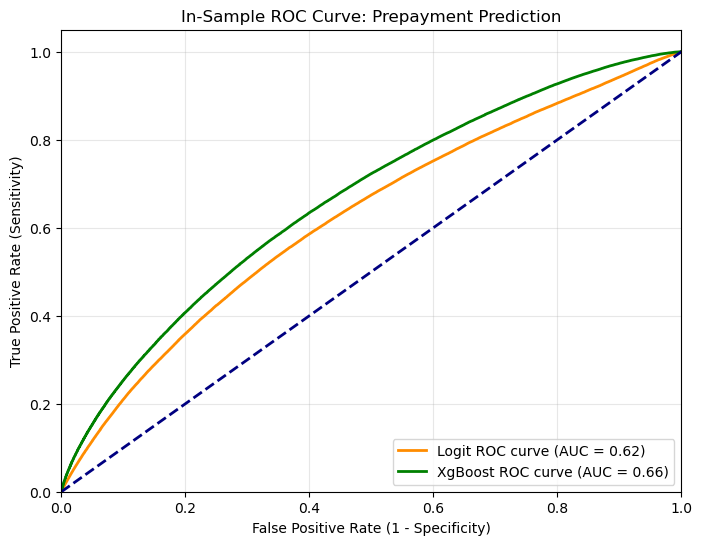

In [8]:

#Calculate the in-sample ROC values
fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = roc_auc_score(y, y_prob)

fpr_boost, tpr_boost, thresholds_boost = roc_curve(y, y_prob_boost)
roc_auc_boost = roc_auc_score(y, y_prob_boost)



# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logit ROC curve (AUC = {roc_auc:.2f})')
plt.plot(fpr_boost, tpr_boost, color='green', lw=2, label=f'XgBoost ROC curve (AUC = {roc_auc_boost:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('In-Sample ROC Curve: Prepayment Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [9]:
#Get actual cumulative prepayment rates by DATE_NOW
#Calculate original UPB
start_upb= mort_est_df[['LOAN_ID', 'ORIG_UPB']].drop_duplicates().set_index('LOAN_ID').sum().values[0]

mort_est_df['PREPAID_UPB'] = mort_est_df['PREPAY_FLAG'] * mort_est_df['ORIG_UPB']*mort_est_df['UPB_MULT']
cum_prepay = mort_est_df.groupby('DATE_NOW')['PREPAID_UPB'].sum().cumsum()/start_upb

In [10]:
mort_est_df.head()

,LOAN_ID,ORIG_RATE,ORIG_UPB,LOAN_AGE,OLTV,MOD_FLAG,CSCORE_MAX,coop_condo_dummy,ORIG_DATE1,def_flag,fb_mod_flag,PREPAY_FLAG,SATO,hpi_growth,refi_benefit_past,DATE_NOW,refi_benefit_now,UPB_MULT,PREPAID_UPB
0,238370511994,3.875,144000.0,57.0,80.0,N,731.0,1,2012-06-01,0,0,0,0.125,0.586552,-10192.417,2017-03-01,2950.104,0.905042,0.0
1,837617881151,5.000,162000.0,59.0,80.0,N,682.0,0,2012-06-01,0,0,0,1.250,0.510822,-35531.516,2017-05-01,-16589.055,0.916007,0.0
2,837617881151,5.000,162000.0,60.0,80.0,N,682.0,0,2012-06-01,0,0,0,1.250,0.543158,-35531.516,2017-06-01,-16962.076,0.914478,0.0
3,837617881151,5.000,162000.0,61.0,80.0,N,682.0,0,2012-06-01,0,0,0,1.250,0.543158,-35531.516,2017-07-01,-18006.121,0.912942,0.0
4,837617881151,5.000,162000.0,62.0,80.0,N,682.0,0,2012-06-01,0,0,0,1.250,0.543158,-35531.516,2017-08-01,-18006.121,0.911400,0.0


In [11]:
X_hypo = mort_pred_df[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 
                       'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']]
X_hypo = sm.add_constant(X_hypo, has_constant='add')
y_prob_hypo = result.predict(X_hypo)

In [12]:
y_prob_hypo_boost=clf.predict_proba(mort_pred_df[['LOAN_AGE', 'OLTV', 'CSCORE_MAX', 'coop_condo_dummy', 
                       'refi_benefit_now', 'refi_benefit_past', 'hpi_growth', 'SATO']])[:, 1]

In [13]:
#Next- use the predicted probabilities to get the expected cumulative prepayment rates over time
#This is a start - need to get cumlative survival rate product up to t-1
#Then loan-level orig_upb*upb_factor*(1-cum_survival_rate)*prepay_probability 
# to get expected prepay at time t
#Then aggretate and divide by total orig_upb to get expected cumulative prepay rate at time t

# 1. Calculate the 'stay' probability for each specific month
mort_pred_df['PREDICTED_PREPAY_PROB'] = y_prob_hypo
mort_pred_df['STAY_PROB'] = 1 - mort_pred_df['PREDICTED_PREPAY_PROB']

# 2. Ensure the data is ordered by loan and time
mort_pred_df = mort_pred_df.sort_values(['LOAN_ID', 'LOAN_AGE'])

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
mort_pred_df['CUM_STAY_PROB'] = mort_pred_df.groupby('LOAN_ID')['STAY_PROB'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
mort_pred_df['LAG_PROD_SURVIVAL'] = (
    mort_pred_df.groupby('LOAN_ID')['CUM_STAY_PROB']
    .shift(1, fill_value=1.0)
)
mort_pred_df.drop(columns=['STAY_PROB', 'CUM_STAY_PROB'], inplace=True)
mort_pred_df['EXPECTED_PREPAID_UPB'] = mort_pred_df['ORIG_UPB'] * mort_pred_df['UPB_MULT']  * (1 - mort_pred_df['LAG_PROD_SURVIVAL']) * mort_pred_df['PREDICTED_PREPAY_PROB']
agg_expected_prepay = mort_pred_df.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB'].sum().cumsum()/start_upb



In [14]:
#Repeat above cell for xgboost results

# 1. Calculate the 'stay' probability for each specific month
mort_pred_df['PREDICTED_PREPAY_PROB_BOOST'] = y_prob_hypo_boost
mort_pred_df['STAY_PROB_BOOST'] = 1 - mort_pred_df['PREDICTED_PREPAY_PROB_BOOST']

# 2. Ensure the data is ordered by loan and time
mort_pred_df = mort_pred_df.sort_values(['LOAN_ID', 'LOAN_AGE'])

# 3. Calculate the cumulative product (running product) per loan
# This gives: (1-P_0) * (1-P_1) * ... * (1-P_n)
mort_pred_df['CUM_STAY_PROB_BOOST'] = mort_pred_df.groupby('LOAN_ID')['STAY_PROB_BOOST'].cumprod()

# 4. Shift the results to get the product of PREVIOUS months only
mort_pred_df['LAG_PROD_SURVIVAL_BOOST'] = (
    mort_pred_df.groupby('LOAN_ID')['CUM_STAY_PROB_BOOST']
    .shift(1, fill_value=1.0)
)
mort_pred_df.drop(columns=['STAY_PROB_BOOST', 'CUM_STAY_PROB_BOOST'], inplace=True)
mort_pred_df['EXPECTED_PREPAID_UPB_BOOST'] = mort_pred_df['ORIG_UPB'] * mort_pred_df['UPB_MULT']  * (1 - mort_pred_df['LAG_PROD_SURVIVAL_BOOST']) * mort_pred_df['PREDICTED_PREPAY_PROB']
agg_expected_prepay_boost = mort_pred_df.groupby('DATE_NOW')['EXPECTED_PREPAID_UPB_BOOST'].sum().cumsum()/start_upb



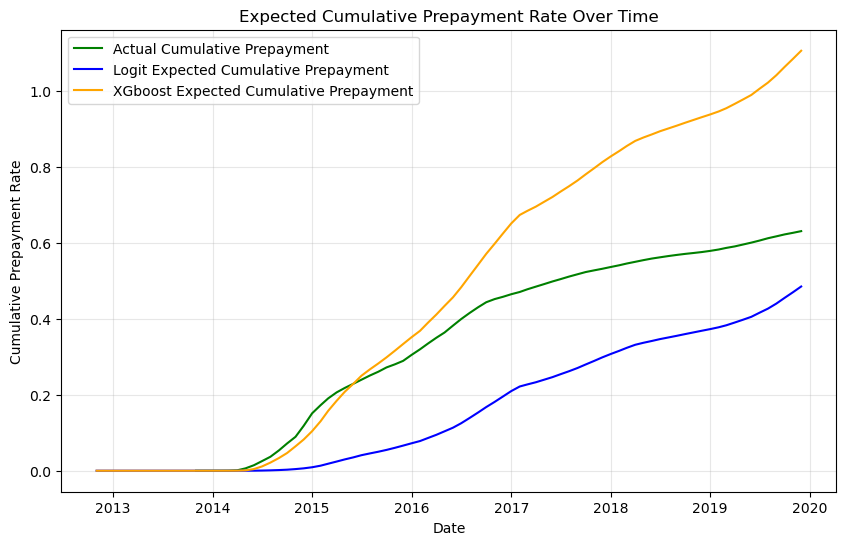

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(cum_prepay.index, cum_prepay.values, label='Actual Cumulative Prepayment', color='Green')
plt.plot(agg_expected_prepay.index, agg_expected_prepay.values, label='Logit Expected Cumulative Prepayment', color='Blue')
plt.plot(agg_expected_prepay_boost.index, agg_expected_prepay_boost.values, label='XGboost Expected Cumulative Prepayment', color='Orange')
plt.xlabel('Date')
plt.ylabel('Cumulative Prepayment Rate')
plt.title('Expected Cumulative Prepayment Rate Over Time')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
import joblib

# To Save
joblib.dump(random_search, 'random_search.pkl')

['random_search.pkl']